# 🎬 Sailing Agent Trajectory Visualizer

This notebook provides an interactive interface for visualizing sailing agent trajectories.

**Features:**
1. **Single Agent Visualization**: Watch your agent navigate through the windfield step-by-step
2. **Multi-Agent Race Mode**: Compare multiple agents racing on the same windfield! 🏁


In [1]:
# If you've modified visualization.py, run this cell to reload it
import importlib
import sys
if 'src.visualization' in sys.modules:
    import src.visualization
    importlib.reload(src.visualization)
    print("✅ Reloaded visualization module")


## Setup


In [2]:
import sys
import os
import numpy as np
import pandas as pd
from IPython.display import display

# Add the src directory to the path
sys.path.append(os.path.abspath('../src'))
sys.path.append(os.path.abspath('..'))

# Import the evaluation and visualization tools
from src.test_agent_validity import validate_agent
from src.evaluation import evaluate_agent, visualize_trajectory
from src.visualization import visualize_race, print_race_summary, create_race_gif
from wind_scenarios import get_wind_scenario, WIND_SCENARIOS

# List available wind scenarios
print("Available windfields:")
for windfield_name in sorted(WIND_SCENARIOS.keys()):
    print(f"  - {windfield_name}")

print("\n✅ Setup complete!")


Available windfields:
  - training_1
  - training_2
  - training_3

✅ Setup complete!


In [3]:
from src.agents.dqn_agent import DQNAgent
import torch
# Use state_size=6 to match the training!
agent = DQNAgent(state_size=6, action_size=9)

# Local path relative to where you run the notebook
weights_path = '/home/pierre/dev/ENSAE/S2/RL/Sailing_RL/src/agents/dqn_weights.pth' 

if os.path.exists(weights_path):
    agent.policy_net.load_state_dict(torch.load(weights_path, map_location='cpu'))
    print("✅ Weights loaded successfully.")
else:
    print(f"❌ Error: Could not find weights at {weights_path}")

agent.policy_net.eval()

 DQNAgent: No weights found. Starting fresh.
✅ Weights loaded successfully.


SailingQNetwork(
  (fc1): Linear(in_features=6, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=128, bias=True)
  (fc3): Linear(in_features=128, out_features=9, bias=True)
)

---
# Part 1: Single Agent Trajectory Viewer

Watch a single agent navigate through the windfield with an interactive slider.


## Configuration


In [4]:
#############################################
### CONFIGURE YOUR VISUALIZATION HERE ######
#############################################

# Agent to visualize
AGENT_PATH = "../src/agents/dqn_agent.py"

# Windfield to use
WINDFIELD_NAME = "training_3"

# Seed for reproducibility
SEED = 1000

# Maximum steps
MAX_STEPS = 500

#############################################

print(f"Agent: {AGENT_PATH}")
print(f"Windfield: {WINDFIELD_NAME}")
print(f"Seed: {SEED}")
print(f"Max steps: {MAX_STEPS}")


Agent: ../src/agents/dqn_agent.py
Windfield: training_3
Seed: 1000
Max steps: 500


## Load and Run Agent


In [5]:
# Load agent
validation_results = validate_agent(AGENT_PATH)
if not validation_results['valid']:
    print("❌ Agent validation failed:")
    for error in validation_results['errors']:
        print(f"  - {error}")
    raise ValueError("Invalid agent")

AgentClass = validation_results['agent_class']
agent = AgentClass()
print(f"✅ Loaded agent: {AgentClass.__name__}")

# Get windfield configuration
wind_scenario = get_wind_scenario(WINDFIELD_NAME)
wind_scenario['env_params'] = {
    'wind_grid_density': 32,  # Show 32x32 arrows despite 128x128 (prevents crowding)
    'wind_arrow_scale': 400,  # Higher scale = shorter arrows (prevents overlap)
    'render_mode': "rgb_array",
    'show_full_trajectory': True # show full trajectory 
}

# Run evaluation with rendering
print(f"\n🎬 Running agent on {WINDFIELD_NAME} with seed {SEED}...")
results = evaluate_agent(
    agent=agent,
    wind_scenario=wind_scenario,
    seeds=SEED,
    max_horizon=MAX_STEPS,
    verbose=False,
    render=True,
    full_trajectory=True
)

# Display results
print(f"\n📊 Results:")
print(f"  Reward: {results['rewards'][0]:.2f}")
print(f"  Steps: {results['steps'][0]}")
print(f"  Success: {'✅' if results['individual_results'][0]['success'] else '❌'}")
print(f"  Frames captured: {len(results['frames'])}")


 DQNAgent: No weights found. Starting fresh.


 DQNAgent: No weights found. Starting fresh.
✅ Loaded agent: DQNAgent

🎬 Running agent on training_3 with seed 1000...


KeyboardInterrupt: 

<Figure size 1000x1000 with 0 Axes>

In [6]:
import torch

# 1. Update paths to your local setup
AGENT_PATH = "../src/agents/dqn_agent.py"
WEIGHTS_PATH = "../src/agents/dqn_weights.pth"
WINDFIELD_NAME = "training_1"  # Let's test the hardest scenario!

# Load and Validate Agent Class
validation_results = validate_agent(AGENT_PATH)
if not validation_results['valid']:
    print("❌ Agent validation failed:")
    for error in validation_results['errors']:
        print(f"  - {error}")
    raise ValueError("Invalid agent")

AgentClass = validation_results['agent_class']

# 2. Initialize with 6 features (Matching your successful training)
agent = AgentClass(state_size=6, action_size=9)

# 3. Load the "Golden" weights
if os.path.exists(WEIGHTS_PATH):
    agent.policy_net.load_state_dict(torch.load(WEIGHTS_PATH, map_location='cpu'))
    agent.policy_net.eval()
    print(f"✅ Loaded agent: {AgentClass.__name__} with weights from {WEIGHTS_PATH}")
else:
    raise FileNotFoundError(f"❌ Weights file not found at {WEIGHTS_PATH}. Did you copy it from Drive?")

# Get windfield configuration
wind_scenario = get_wind_scenario(WINDFIELD_NAME)
wind_scenario['env_params'] = {
    'wind_grid_density': 32,
    'wind_arrow_scale': 400,
    'render_mode': "rgb_array",
    'show_full_trajectory': True 
}

# Run evaluation
print(f"\n🎬 Running agent on {WINDFIELD_NAME} with seed {SEED}...")
results = evaluate_agent(
    agent=agent,
    wind_scenario=wind_scenario,
    seeds=SEED,
    max_horizon=MAX_STEPS,
    verbose=False,
    render=True,
    full_trajectory=True
)

# Display results
print(f"\n📊 Results:")
print(f"  Reward: {results['rewards'][0]:.2f}")
print(f"  Steps: {results['steps'][0]}")
print(f"  Success: {'✅' if results['individual_results'][0]['success'] else '❌'}")

 DQNAgent: No weights found. Starting fresh.
 DQNAgent: No weights found. Starting fresh.
✅ Loaded agent: DQNAgent with weights from ../src/agents/dqn_weights.pth

🎬 Running agent on training_1 with seed 1000...

📊 Results:
  Reward: 100.00
  Steps: 167
  Success: ✅


## Interactive Trajectory Viewer


In [7]:
# Display interactive slider
visualize_trajectory(results, with_slider=True)


interactive(children=(IntSlider(value=0, description='Step:', max=166), Output()), _dom_classes=('widget-inter…

---
# Part 2: Multi-Agent Race Viewer 🏁

Watch multiple agents race against each other on the same windfield!

**Note:** All agents will face the exact same wind conditions (same windfield + seed).


## Configuration


In [8]:
#############################################
### CONFIGURE YOUR RACE HERE ###############
#############################################

# Agents to race (add as many as you want!)
RACE_AGENTS = [
    {"path": "../src/agents/agent_super_naive.py", "name": "Agent Super Naive", "color": "black"},
    {"path": "../src/agents/agent_trained_example.py", "name": "Agent QLearning", "color": "pink"},
    {"path": "../src/agents/dqn_agent.py", "name": "Agent DeepQLearning", "color": "green"}
]

# Race windfield
RACE_WINDFIELD = "training_1"

# Race seed
RACE_SEED = 1001

# Maximum steps
RACE_MAX_STEPS = 500

#############################################

print(f"🏁 Race Configuration:")
print(f"  Windfield: {RACE_WINDFIELD}")
print(f"  Seed: {RACE_SEED}")
print(f"  Agents: {len(RACE_AGENTS)}")
for i, agent_info in enumerate(RACE_AGENTS):
    print(f"    {i+1}. {agent_info['name']} ({agent_info['color']})")


🏁 Race Configuration:
  Windfield: training_1
  Seed: 1001
  Agents: 3
    1. Agent Super Naive (black)
    2. Agent QLearning (pink)
    3. Agent DeepQLearning (green)


## Run All Agents


In [11]:
# Load and run all agents
race_results = []

for agent_info in RACE_AGENTS:
    print(f"\n🤖 Loading {agent_info['name']}...")
    
    # Load agent
    validation_results = validate_agent(agent_info['path'])
    if not validation_results['valid']:
        print(f"  ❌ Validation failed for {agent_info['name']}")
        continue
    
    AgentClass = validation_results['agent_class']
    agent = AgentClass()
    
    # Get windfield (must be same for all agents)
    wind_scenario = get_wind_scenario(RACE_WINDFIELD)
    wind_scenario['env_params'] = {
    'wind_grid_density': 32,  # Show 32x32 arrows despite 128x128 (prevents crowding)
    'wind_arrow_scale': 400,  # Higher scale = shorter arrows (prevents overlap)
}
    
    # Run evaluation (without rendering individual frames, we'll render the race custom)
    results = evaluate_agent(
        agent=agent,
        wind_scenario=wind_scenario,
        seeds=RACE_SEED,
        max_horizon=RACE_MAX_STEPS,
        verbose=False,
        render=False,  # We'll do custom rendering
        full_trajectory=True
    )
    
    # Store results with agent info
    race_results.append({
        'name': agent_info['name'],
        'color': agent_info['color'],
        'positions': results['positions'],
        'actions': results['actions'],
        'reward': results['rewards'][0],
        'steps': results['steps'][0],
        'success': results['individual_results'][0]['success']
    })
    
    print(f"  ✅ Reward: {results['rewards'][0]:.2f}, Steps: {results['steps'][0]}, Success: {results['individual_results'][0]['success']}")

print(f"\n✅ All {len(race_results)} agents completed!")



🤖 Loading Agent Super Naive...
  ✅ Reward: 100.00, Steps: 174, Success: True

🤖 Loading Agent QLearning...
  ✅ Reward: 100.00, Steps: 151, Success: True

🤖 Loading Agent DeepQLearning...
 DQNAgent: No weights found. Starting fresh.
 DQNAgent: No weights found. Starting fresh.
  ✅ Reward: 0.00, Steps: 500, Success: False

✅ All 3 agents completed!


## Race Visualization

Use the slider to watch all agents move through the windfield simultaneously!


In [12]:
# Visualize the race using the visualization module!
visualize_race(race_results, RACE_WINDFIELD, RACE_SEED, 
               show_full_trajectories=True)  # ← Add this parameter

interactive(children=(IntSlider(value=0, description='Race Step:', max=499), Output()), _dom_classes=('widget-…

## Race Summary


In [13]:
# Display race summary using the visualization module
print_race_summary(race_results)



RACE RESULTS


,Agent,Color,Steps,Reward,Success
1,Agent QLearning,pink,151,100.00,Yes
0,Agent Super Naive,black,174,100.00,Yes
2,Agent DeepQLearning,green,500,0.00,No



WINNER: Agent QLearning (completed in 151 steps!)


## Create GIF Animation

Run this cell to export the race as an animated GIF file!


Creating race GIF...


KeyboardInterrupt: 

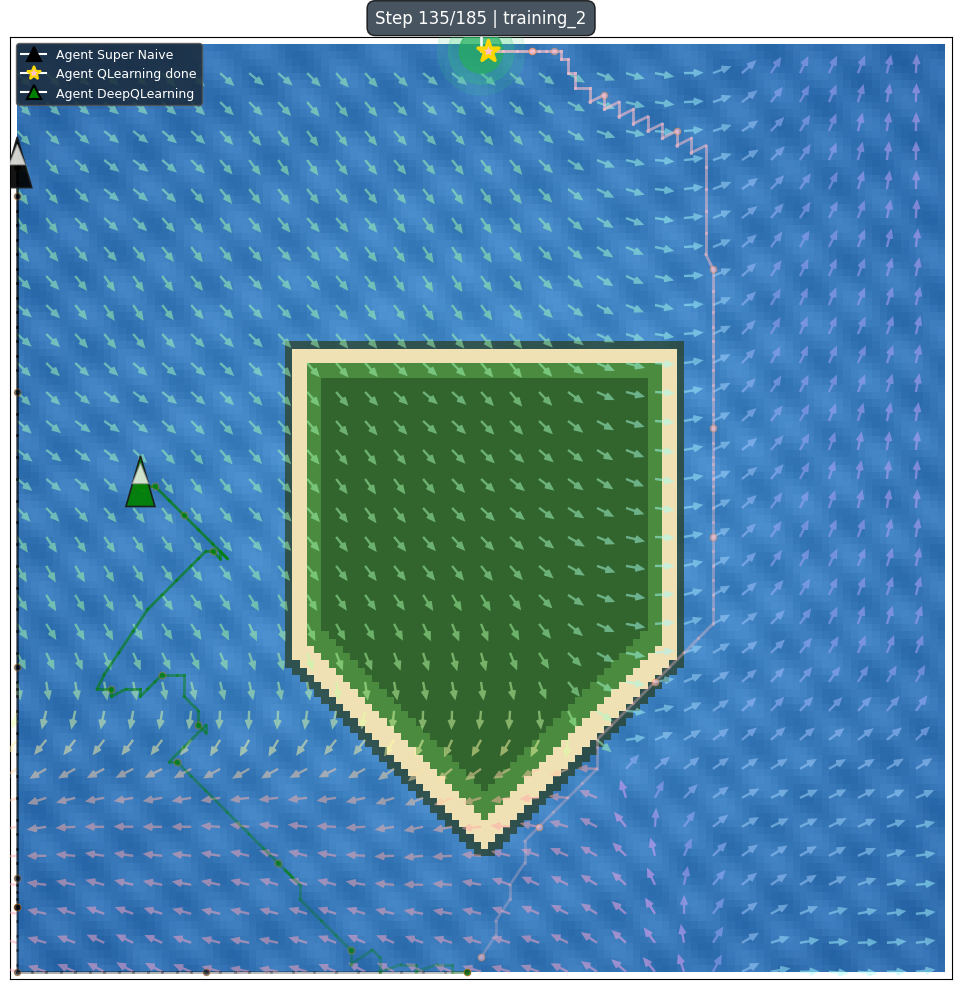

In [ ]:
#############################################
### GIF CONFIGURATION #######################
#############################################

# Enable/disable GIF creation
CREATE_GIF = False # Set to True to create a GIF

# GIF settings
GIF_OUTPUT_PATH = "race_animation.gif"  # Where to save the GIF
GIF_FPS = 10  # Frames per second (higher = faster animation)
GIF_STEP_INTERVAL = 1  # 1 = every step, 2 = every other step (reduces file size)

#############################################

if CREATE_GIF:
    if 'race_results' not in locals():
        print("⚠️ Please run the race evaluation cells first!")
    else:
        create_race_gif(
            race_results=race_results,
            windfield_name=RACE_WINDFIELD,
            seed=RACE_SEED,
            output_path=GIF_OUTPUT_PATH,
            fps=GIF_FPS,
            step_interval=GIF_STEP_INTERVAL,
            show_full_trajectories=True  # ← Add this parameter
        )
else:
    print("ℹ️ GIF creation is disabled. Set CREATE_GIF = True to enable.")


**GIF Parameters:**
- `GIF_FPS`: Controls animation speed (10 = normal, 15 = faster, 5 = slower)
- `GIF_STEP_INTERVAL`: Sample every N steps (1 = all frames, 2 = half frames)
- Higher step interval = smaller file size but less smooth

**Note:** You need to install `imageio` to create GIFs:
```bash
pip install imageio
```
